### 🌍 Projeto de Data Science

**Análise Global de PIB, População e Expectativa de Vida (1952–2007)**

#### 📌 Contexto do Problema

O desenvolvimento econômico e social de um país pode ser analisado através de indicadores fundamentais como:

    PIB per capita
    Expectativa de vida
    População

Esses indicadores permitem avaliar nível de desenvolvimento, qualidade de vida e crescimento econômico.

Neste projeto realizamos uma análise exploratória de dados (EDA) para entender:

* Como PIB per capita evoluiu ao longo do tempo
* Diferenças de desenvolvimento entre continentes
* Relação entre riqueza e expectativa de vida
* Distribuição da população mundial

#### 🎯 Objetivos da Análise

Responder perguntas importantes:

* Quais continentes possuem maior PIB per capita médio?
* Existe correlação entre riqueza e expectativa de vida?
* Como população e PIB evoluíram ao longo do tempo?
* Existem desigualdades econômicas entre continentes?

## Instalando e Carregando os Pacotes

In [1]:
# Imports

import math
import random
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 

In [2]:
dados = pd.read_csv('dados/dataset6.csv', sep='\t')

In [3]:
dados.shape

(1704, 6)

In [4]:
dados.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333.0,779.445314
1,Afghanistan,Asia,1957,30.332,9240934.0,820.853030
2,Afghanistan,Asia,1962,31.997,10267083.0,853.100710
3,Afghanistan,Asia,1967,34.020,11537966.0,836.197138
4,Afghanistan,Asia,1972,36.088,13079460.0,739.981106


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB


#### Observações:

    Não há valores nulos
    Dados incluem 142 países
    Período analisado: 1952 a 2007

In [6]:
first_year = dados['year'].min()
first_year

1952

In [7]:
latest_year = dados['year'].max()
latest_year

2007

In [8]:
dados['gdpPercap'].describe()

count      1704.000000
mean       7215.327081
std        9857.454543
min         241.165876
25%        1202.060309
50%        3531.846988
75%        9325.462346
max      113523.132900
Name: gdpPercap, dtype: float64

Principais insights:

    PIB médio global: ≈ 7.200 USD
    Grande desigualdade entre países
    Máximo superior a 113 mil USD

Isso indica forte concentração de riqueza em poucos países.

**Boxplot com a distribuição do PIB Per-Capita por continente**

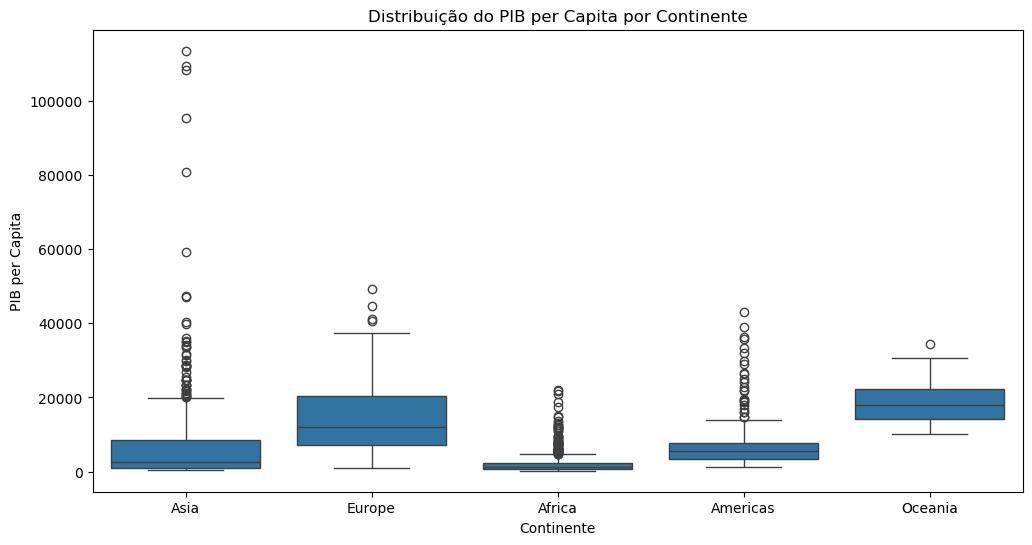

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dados,
    x="continent",
    y="gdpPercap"
)

plt.title("Distribuição do PIB per Capita por Continente")
plt.xlabel("Continente")
plt.ylabel("PIB per Capita")
plt.show()

O gráfico mostra que:

    Europa e Américas possuem maiores PIBs per capita
    África concentra os menores valores
    Há grande desigualdade interna na Ásia

#### Relação entre PIB e Expectativa de Vida

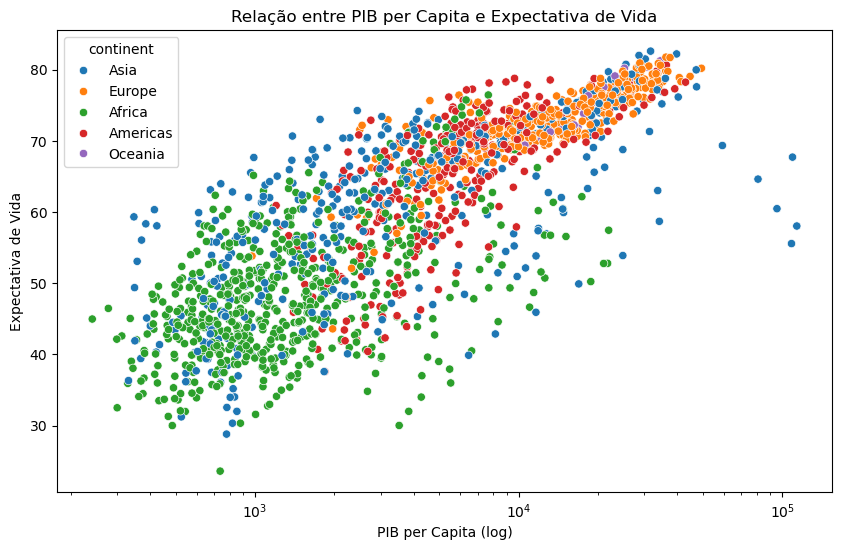

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dados,
    x="gdpPercap",
    y="lifeExp",
    hue="continent"
)

plt.xscale("log")

plt.title("Relação entre PIB per Capita e Expectativa de Vida")
plt.xlabel("PIB per Capita (log)")
plt.ylabel("Expectativa de Vida")

plt.show()

Existe uma correlação positiva clara:

Países mais ricos tendem a ter maior expectativa de vida

Mas a relação não é linear perfeita, indicando influência de fatores como:

    políticas públicas
    acesso à saúde
    educação

**Quantidade de Países por Continente**

In [11]:
countries = dados[['country', 'continent']]
countries = countries.drop_duplicates()

In [12]:
countries.shape   

(142, 2)

In [13]:
country_counts = countries.groupby('continent', as_index = False)['country'].count()
country_counts

,continent,country
0,Africa,52
1,Americas,25
2,Asia,33
3,Europe,30
4,Oceania,2


***Renomeando a coluna***

In [22]:
country_counts.columns = ['continent', 'n_countries']
country_counts

,continent,n_countries
0,Africa,52
1,Americas,25
2,Asia,33
3,Europe,30
4,Oceania,2


**Boxplot e Stripplot com a distribuição da expectativa de vida por continente**

Text(0, 0.5, 'Expectativa de Vida')

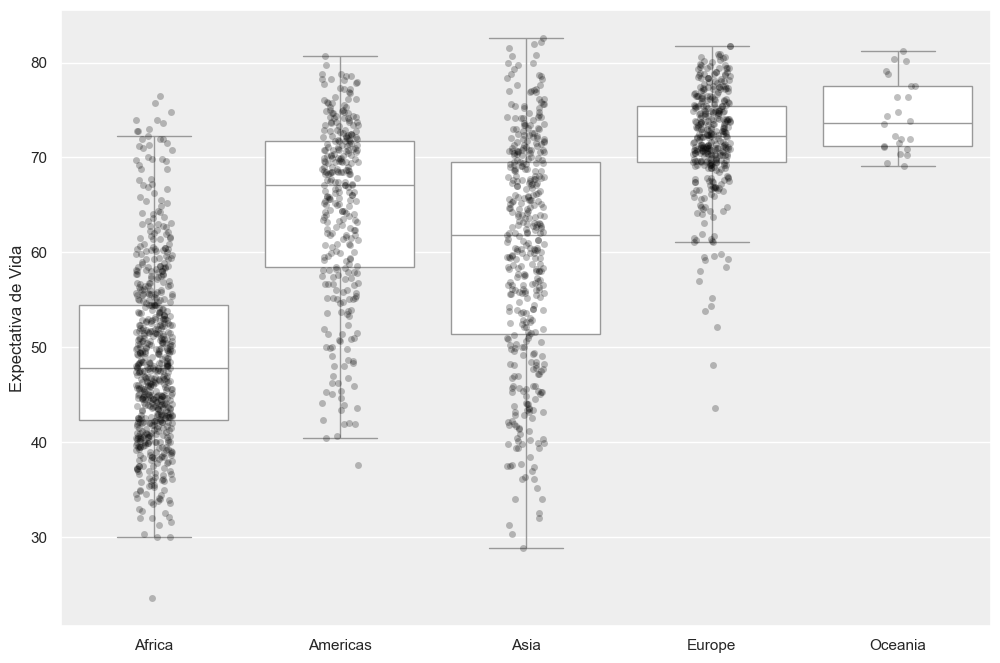

In [20]:
# Dataviz
sns.set(rc = {'axes.facecolor' : '#EEEEEE'})
plt.figure(figsize = (12, 8))

sns.boxplot(x = "continent", 
            y = "lifeExp", 
            data = dados,
            order = np.sort(dados.continent.unique()),
            color = 'white', 
            fliersize = 0)

sns.stripplot(x = "continent", 
              y = "lifeExp", 
              data = dados,
              order = np.sort(dados.continent.unique()),
              alpha = 0.25, 
              size = 5, 
              jitter = True,
              color = 'Black', 
              edgecolor = 'Black')

plt.xlabel('')
plt.ylabel('Expectativa de Vida')

# Fim